In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_absolute_error, mean_squared_error, r2_score, roc_curve, auc, precision_recall_curve


In [2]:
# Load data
with np.load('/home/server/Projects/data/AKI/preop_trainable/unfiltered_andrew.npz', allow_pickle=True) as data:
    X_train = data["X_train"]
    X_test = data["X_test"]
    y_train = data["y_train"]
    y_test = data["y_test"]
    y_binary_train = data["y_binary_train"]
    y_binary_test = data["y_binary_test"]
    y_positive_train = data["y_positive_train"]
    y_positive_test = data["y_positive_test"]

In [3]:
# Train KNN Regressor
knn_regressor = KNeighborsRegressor(n_neighbors=200)
knn_regressor.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=200)

In [4]:
# Predict
y_pred = knn_regressor.predict(X_test)

# Regression Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: {mae:.4f}')
print(f'Mean Squared Error: {mse:.4f}')
print(f'Root Mean Squared Error: {rmse:.4f}')
print(f'R-squared: {r2:.4f}')

Mean Absolute Error: 0.3227
Mean Squared Error: 0.1849
Root Mean Squared Error: 0.4300
R-squared: -1.1654


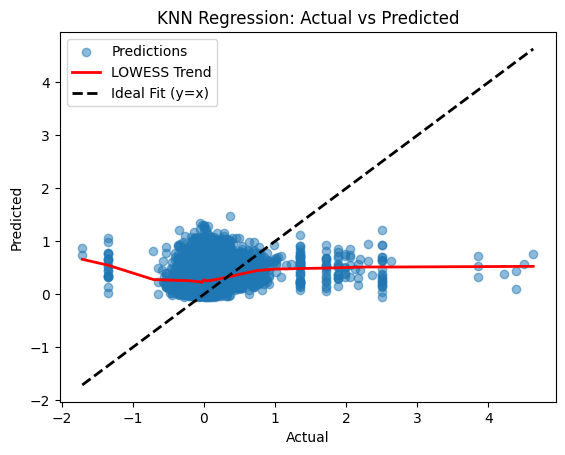

In [7]:
# Plot actual vs predicted values
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5, label="Predictions")

# Fit LOWESS smoother (better for non-parametric models like KNN)
import statsmodels.api as sm
lowess = sm.nonparametric.lowess(y_pred, y_test, frac=0.3)
plt.plot(lowess[:, 0], lowess[:, 1], color='red', linewidth=2, label="LOWESS Trend")

# Identity line (y = x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label="Ideal Fit (y=x)")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("KNN Regression: Actual vs Predicted")
plt.legend()
plt.show()

In [3]:
# Train KNN Classifier
# NOTE:: This is using a binary classification target.
# This might cause issues, so below will be using the KNRegressor to predict the probability of AKI
knn_classifier = KNeighborsClassifier(n_neighbors=200)
knn_classifier.fit(X_train, y_binary_train)


KNeighborsClassifier(n_neighbors=200)

In [4]:
# Predict binary outcomes
y_pred_binary = knn_classifier.predict(X_test)

# Classification Metrics
accuracy = accuracy_score(y_binary_test, y_pred_binary)
print(f'Accuracy: {accuracy:.2f}')

cm = confusion_matrix(y_binary_test, y_pred_binary)
print('Confusion Matrix:')
print(cm)

report = classification_report(y_binary_test, y_pred_binary)
print('Classification Report:')
print(report)

Accuracy: 0.68
Confusion Matrix:
[[7591 3430]
 [ 271  427]]
Classification Report:
              precision    recall  f1-score   support

       False       0.97      0.69      0.80     11021
        True       0.11      0.61      0.19       698

    accuracy                           0.68     11719
   macro avg       0.54      0.65      0.50     11719
weighted avg       0.91      0.68      0.77     11719



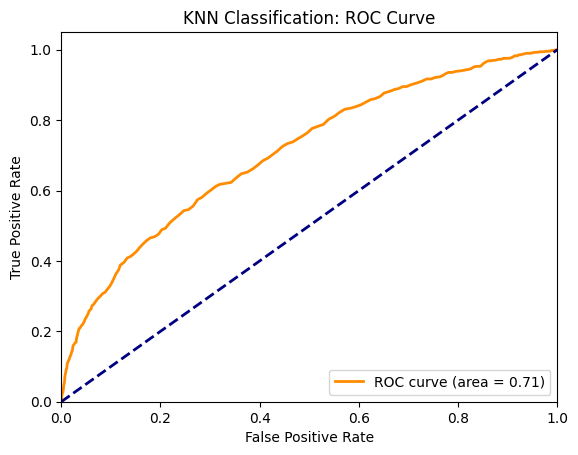

In [5]:
# Predict probabilities for ROC curve
y_prob = knn_classifier.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_binary_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('KNN Classification: ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [18]:
performance_dict(y_binary_test, y_pred_binary, y_prob)

{'Precision': 0.11070780399274047,
 'Sensitivity': 0.6117478510028653,
 'Accuracy': 0.6841880706544927,
 'rc_auc': 0.7096021947160528,
 'pr_auc': 0.17195938724513637,
 'Specificity': 0.6887759731421831,
 'Negative Precision': 0.9655303993894683,
 'Pos F1 Score': 0.18748627881448957}

In [ ]:
# Using KNN Regressor to predict probability of AKI
# Convert predictions to binary (Threshold: 0.3)
y_pred_binary = y_pred > 0.3

In [12]:
print("\nBinary Classification (Threshold = 0.3):")

accuracy = accuracy_score(y_binary_test, y_pred_binary)
print(f'Accuracy: {accuracy:.2f}')

cm = confusion_matrix(y_binary_test, y_pred_binary)
print('Confusion Matrix:')
print(cm)

report = classification_report(y_binary_test, y_pred_binary)
print('Classification Report:')
print(report)


Binary Classification (Threshold = 0.3):
Accuracy: 0.62
Confusion Matrix:
[[5910 3686]
 [ 234  425]]
Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.62      0.75      9596
        True       0.10      0.64      0.18       659

    accuracy                           0.62     10255
   macro avg       0.53      0.63      0.46     10255
weighted avg       0.91      0.62      0.71     10255



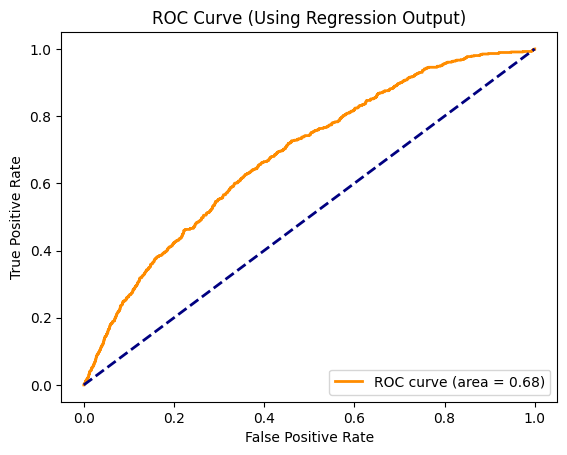

In [13]:
# ROC Curve
y_prob = y_pred  # Use regression output directly as probability
fpr, tpr, _ = roc_curve(y_binary_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Using Regression Output)')
plt.legend(loc='lower right')
plt.show()